# L2.3 — Train / Val / Test, K-Fold, and Data Leakage

Hands-on notebook for the lesson [`2-3-train-val-test.mdx`](../../llm-quest-theory/level-2/2-3-train-val-test.mdx).

> **Learning objectives**
> - Compare a single holdout split vs K-fold cross-validation on the same model.
> - Build a practical stratified train/val/test split for imbalanced data.
> - See data leakage in action — fit the scaler on the wrong split and watch the test score become dishonest.
> - Read a learning curve (more training data → what happens to train and val loss?).

## Connection to the theory
Covers **§1–§7** of the source `.mdx`. The lesson's central rule: *tune on validation, report on test, open the test set exactly once*.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Build a mildly imbalanced dataset
900 samples, class 1 is only ~10% — enough that a random split can skew the test label ratio.

In [2]:
X, y = make_classification(
    n_samples=900, n_features=10, n_informative=5, n_redundant=2,
    weights=[0.9, 0.1], class_sep=0.8, random_state=SEED
)
print("class balance:", np.bincount(y), " overall rate:", round(y.mean(), 3))

class balance: [802  98]  overall rate: 0.109


## 2. Plain holdout vs stratified holdout
Without stratification the test set's class ratio drifts. With stratification it matches the parent distribution.

In [3]:
# Plain
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(X, y, test_size=0.2, random_state=0)
# Stratified
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X, y, test_size=0.2,
                                              stratify=y, random_state=0)
print(f"plain test class-1 rate     : {y_te1.mean():.3f}")
print(f"stratified test class-1 rate: {y_te2.mean():.3f}  (matches overall {y.mean():.3f})")

plain test class-1 rate     : 0.117
stratified test class-1 rate: 0.111  (matches overall 0.109)


## 3. 70 / 15 / 15 stratified split
`train_test_split` doesn't do three-way splits directly — do it in two calls.

In [4]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
# 0.15 / 0.85 of the remaining 85% gives us 15% validation overall
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85, stratify=y_tv, random_state=SEED)

for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:<5} size={len(arr):>3}  class-1 rate={arr.mean():.3f}")

train size=630  class-1 rate=0.108
val   size=135  class-1 rate=0.111
test  size=135  class-1 rate=0.111


## 4. K-Fold cross-validation
Evaluate the same model 5 times across rotating validation folds. This gives us a loss distribution, not a single point estimate.

In [5]:
pipe = Pipeline([("scaler", StandardScaler()),
                 ("clf",    LogisticRegression(max_iter=2000))])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scores = cross_val_score(pipe, X_tv, y_tv, cv=skf, scoring="accuracy")
print("5-fold accuracies:", np.round(scores, 3))
print(f"mean = {scores.mean():.3f}  std = {scores.std():.3f}")

5-fold accuracies: [0.895 0.902 0.902 0.889 0.895]
mean = 0.897  std = 0.005


## 5. Data leakage demo — scale on the full dataset
We intentionally do the **wrong** thing: fit the scaler on the whole `X` before splitting. This lets information from the test rows leak into the training pipeline.

Effect on this toy problem is small, but the pattern is real. On noisier or higher-dim problems it can manufacture 5-10% "free" accuracy that disappears in production.

In [6]:
# Wrong: scale on the full data before splitting
X_leaky = StandardScaler().fit_transform(X)
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_leaky, y, test_size=0.2, stratify=y, random_state=SEED)
clf_l = LogisticRegression(max_iter=2000).fit(X_tr_l, y_tr_l)
acc_leaky = accuracy_score(y_te_l, clf_l.predict(X_te_l))

# Right: pipeline scales inside the train split only, via cross_val_score
pipe2 = Pipeline([("scaler", StandardScaler()),
                  ("clf",    LogisticRegression(max_iter=2000))])
acc_clean = cross_val_score(pipe2, X, y, cv=skf, scoring="accuracy").mean()

print(f"leaky pipeline accuracy (single split): {acc_leaky:.4f}")
print(f"honest pipeline accuracy (5-fold mean): {acc_clean:.4f}")

leaky pipeline accuracy (single split): 0.8889
honest pipeline accuracy (5-fold mean): 0.8944


Why is leakage insidious? The leaky pipeline's single-split estimate is *also* a single-sample statistic — noisy — so you can't always tell from the number alone. The fix is procedural, not numerical: never let preprocessing see the validation / test rows.

## 6. Learning curve — does more data help?
Use scikit-learn's `learning_curve` to plot train vs cross-validated accuracy as we add more training data.

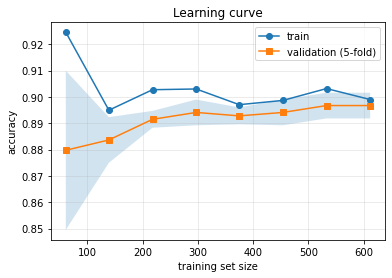

In [7]:
train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_tv, y_tv, cv=skf,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy", random_state=SEED
)

fig, ax = plt.subplots()
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="train")
ax.plot(train_sizes, val_scores.mean(axis=1),   "s-", label="validation (5-fold)")
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
ax.set_xlabel("training set size"); ax.set_ylabel("accuracy")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("Learning curve")
plt.show()

Read the plot:
- Large train/val gap that closes as data grows → more data is helping reduce variance.
- Both curves plateau at a low score → the model itself is the bottleneck (underfitting). More data won't help; a better model might.

## 7. Open the test set exactly once
The discipline: after all tuning happens on `X_val`, the very last thing we do is evaluate on `X_test`.

In [8]:
# Step 1 — pick the model / hyperparameters using only train/val (pretend we tried many):
best_pipe = Pipeline([("scaler", StandardScaler()),
                      ("clf",    LogisticRegression(max_iter=2000, C=1.0))])
best_pipe.fit(X_train, y_train)
val_acc = accuracy_score(y_val, best_pipe.predict(X_val))
print(f"validation accuracy used for tuning: {val_acc:.3f}")

# Step 2 — only NOW evaluate on test
test_acc = accuracy_score(y_test, best_pipe.predict(X_test))
print(f"final reported test accuracy       : {test_acc:.3f}")

validation accuracy used for tuning: 0.896
final reported test accuracy       : 0.889


## 8. Quick checks

In [9]:
# Stratification really keeps the ratio close
assert abs(y_test.mean() - y.mean()) < 0.02,  "stratified test must match the parent ratio"
# 5-fold gives a stable mean accuracy
assert 0.7 <= scores.mean() <= 0.95, "5-fold accuracy should land in a sensible range"
# Train size grows monotonically in the learning curve
assert np.all(np.diff(train_sizes) > 0)
# Test accuracy should not be wildly higher than validation
assert abs(test_acc - val_acc) < 0.1, "big val/test gap hints at overfitting to validation"
print("OK — splits, folds, and the evaluation protocol look healthy.")

OK — splits, folds, and the evaluation protocol look healthy.


## Reflection questions

1. Why is a *pipeline* (scaler + classifier) the right object to pass into `cross_val_score`, not a pre-scaled `X_leaky`?
2. K-fold gives you a mean and a standard deviation. When would you prefer a single holdout anyway?
3. If the learning curve's train and val lines both plateau very close together but at a low score, is that overfitting or underfitting? What do you change first?
4. A colleague trained 50 models, picked the one with the best test accuracy, and reports that number. What is wrong, and how would you redesign their workflow?

## References
- Source theory: [`2-3-train-val-test.mdx`](../../llm-quest-theory/level-2/2-3-train-val-test.mdx)
- Next: [`2-4-bias-variance`](2-4-bias-variance.ipynb)